# Model Training
### HBV-Related Hepatocellular Carcinoma (HBV-HCC) Early Detection
---
This notebook trains and evaluates three machine learning models on the
71 LASSO-selected gene expression features to classify HCC tumor vs
non-tumor liver tissue.

**Models:** Random Forest, XGBoost, Support Vector Machine (SVM)  
**Input:** `data/X_lasso.csv`, `data/y_labels.csv`  
**Output:** Trained models saved to `models/`, evaluation plots to `results/`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, roc_auc_score,
                             classification_report, roc_curve,
                             ConfusionMatrixDisplay)
from xgboost import XGBClassifier

print("All libraries loaded successfully")

All libraries loaded successfully


## Step 1: Load LASSO-Selected Features and Labels

In [2]:
# Load LASSO-selected features and labels
X = pd.read_csv('../data/X_lasso.csv', index_col=0)
y = pd.read_csv('../data/y_labels.csv', index_col=0).squeeze()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nLabel distribution:\n{y.value_counts()}")

X shape: (468, 71)
y shape: (468,)

Label distribution:
label
0    239
1    229
Name: count, dtype: int64


## Step 2: Train/Test Split
We split the data 80/20; 80% for training the models, 20% for testing.
Stratification ensures both splits maintain the same tumor/non-tumor ratio.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")
print(f"\nTraining label distribution:\n{y_train.value_counts()}")
print(f"\nTesting label distribution:\n{y_test.value_counts()}")

Training set: 374 samples
Testing set:  94 samples

Training label distribution:
label
0    191
1    183
Name: count, dtype: int64

Testing label distribution:
label
0    48
1    46
Name: count, dtype: int64


## Step 3: Train Models
We train three models; Random Forest, XGBoost, and SVM  on the
training set. Each model learns the relationship between the 71 gene
expression features and the tumor/non-tumor labels.

In [6]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print(" Random Forest trained")

# XGBoost
xgb = XGBClassifier(n_estimators=100, random_state=42,
                    eval_metric='logloss', n_jobs=-1)
xgb.fit(X_train, y_train)
print(" XGBoost trained")

# SVM
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train, y_train)
print(" SVM trained")

print("\nAll models trained successfully!")

 Random Forest trained
 XGBoost trained
 SVM trained

All models trained successfully!


## Step 4: Evaluate Models
We evaluate each model on the test set using:
- **Accuracy** - percentage of correct predictions
- **AUC-ROC** - ability to distinguish tumor from non-tumor (1.0 = perfect)
- **Classification Report** - precision, recall, F1-score per class

In [7]:
models = {
    'Random Forest': rf,
    'XGBoost': xgb,
    'SVM': svm
}

results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    results[name] = {'Accuracy': acc, 'AUC-ROC': auc}
    
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  AUC-ROC:  {auc:.4f}")
    print(f"\n{classification_report(y_test, y_pred, target_names=['Non-Tumor', 'Tumor'])}")


  Random Forest
  Accuracy: 0.9681
  AUC-ROC:  0.9962

              precision    recall  f1-score   support

   Non-Tumor       0.94      1.00      0.97        48
       Tumor       1.00      0.93      0.97        46

    accuracy                           0.97        94
   macro avg       0.97      0.97      0.97        94
weighted avg       0.97      0.97      0.97        94


  XGBoost
  Accuracy: 0.9787
  AUC-ROC:  0.9941

              precision    recall  f1-score   support

   Non-Tumor       0.96      1.00      0.98        48
       Tumor       1.00      0.96      0.98        46

    accuracy                           0.98        94
   macro avg       0.98      0.98      0.98        94
weighted avg       0.98      0.98      0.98        94


  SVM
  Accuracy: 0.9681
  AUC-ROC:  0.9995

              precision    recall  f1-score   support

   Non-Tumor       0.94      1.00      0.97        48
       Tumor       1.00      0.93      0.97        46

    accuracy                  

## Step 5: Save Trained Models
We save all three trained models to the models/ folder using joblib
so they can be reloaded later without retraining.

In [8]:
# Save all three models
joblib.dump(rf, '../models/random_forest.pkl')
joblib.dump(xgb, '../models/xgboost.pkl')
joblib.dump(svm, '../models/svm.pkl')

print("Models saved successfully!")
print("  - models/random_forest.pkl")
print("  - models/xgboost.pkl")
print("  - models/svm.pkl")

Models saved successfully!
  - models/random_forest.pkl
  - models/xgboost.pkl
  - models/svm.pkl


## Step 6: ROC Curves
The ROC curve plots the True Positive Rate against the False Positive Rate
at different thresholds. A curve closer to the top-left corner indicates
a better model. AUC (Area Under Curve) summarises this in one number -
closer to 1.0 is better.

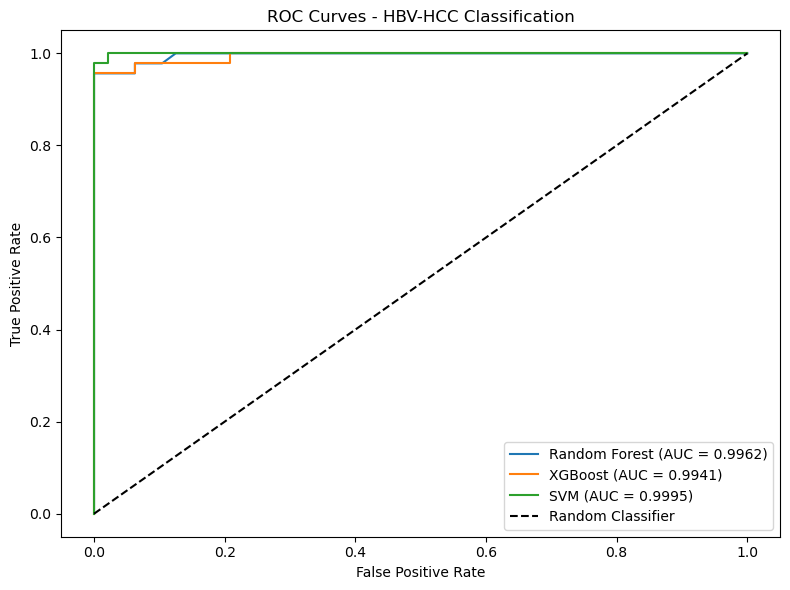

ROC curve saved to results/roc_curves.png


In [9]:
plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - HBV-HCC Classification')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../results/roc_curves.png', dpi=150)
plt.show()
print("ROC curve saved to results/roc_curves.png")

## Step 7: Confusion Matrices
A confusion matrix shows exactly where each model is making correct
predictions and where it is making mistakes.

- Top-left: Correctly predicted Non-Tumor (True Negative)
- Top-right: Non-Tumor predicted as Tumor (False Positive)
- Bottom-left: Tumor predicted as Non-Tumor (False Negative)
- Bottom-right: Correctly predicted Tumor (True Positive)

In cancer detection, False Negatives are the most dangerous error -
missing a real tumor.

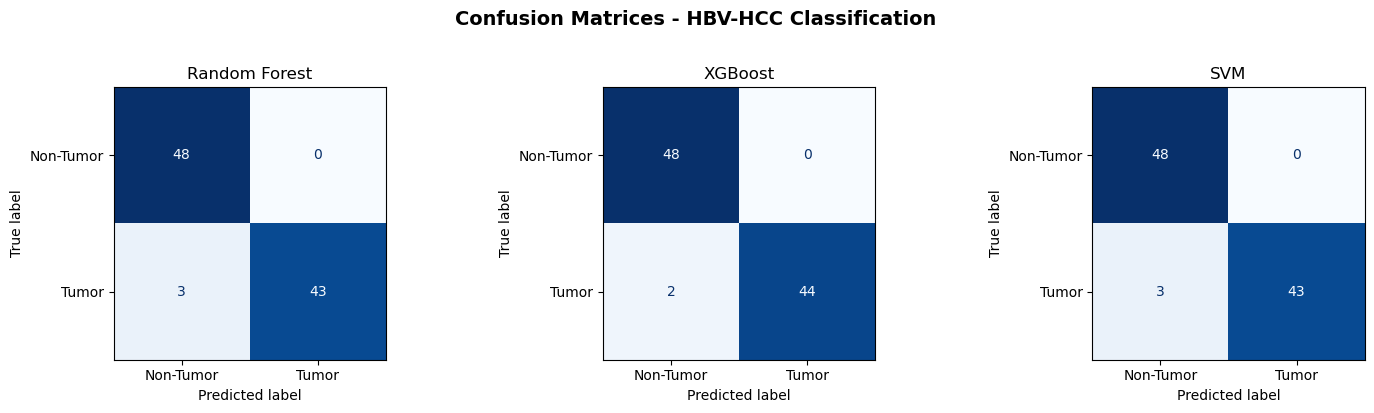

Confusion matrices saved to results/confusion_matrices.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Non-Tumor', 'Tumor'],
        ax=ax,
        colorbar=False,
        cmap='Blues'
    )
    ax.set_title(name)

plt.suptitle('Confusion Matrices - HBV-HCC Classification', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrices saved to results/confusion_matrices.png")

## Summary

Three machine learning models were trained and evaluated on the 71
LASSO-selected gene expression features for HBV-HCC classification.

| Model | Accuracy | AUC-ROC | False Negatives |
|-------|----------|---------|-----------------|
| Random Forest | 96.81% | 0.9962 | 3 |
| XGBoost | 97.87% | 0.9941 | 2 |
| SVM | 96.81% | 0.9995 | 3 |

**Key findings:**
- All three models achieved above 96% accuracy on the test set
- All three models achieved AUC-ROC above 0.99
- XGBoost achieved the highest accuracy (97.87%) and fewest missed
  tumors (2 false negatives)
- SVM achieved the highest AUC-ROC (0.9995)
- Zero false positives across all three models

**Recommendation:** XGBoost is the primary recommended model for
HBV-HCC early detection based on highest accuracy and lowest
false negative rate.

Trained models have been saved to the `models/` folder for use
in cross-cohort validation and deployment.